# Lab Tasks - Solutions

A **collaboration network** in a company captures the relationships between employees who have worked together on the same projects. This type of network analysis is commonly used in organisational studies to understand team dynamics and collaboration patterns.

In this lab we will create this kind of network from an input data file and perform some basic characterisation of the network.

In [2]:
import networkx as nx
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

## Task 1

The file *projects.txt* contains information about the projects undertaken by an IT company. Each line in the file represents a different project and contains the list of employees who worked on that project.

Read in the file *projects.txt*. From this data, create a new **weighted undirected** network that represents the collaborations between employees in the company. Each employee should be represented by a node. An edge should exist between two employees if they have collaborated on at least one project. The weight of each edge should indicate the number of projects on which they have collaborated.

In [4]:
# firstly, read in the data
with open("lab02-data/projects.txt", "r") as fin:
    lines = fin.readlines()

# get the list of employee names for each project
projects = []
for line in lines:
    names = line.strip().split(",")
    projects.append(names)

print(f"Read data for {len(projects)} projects")

Read data for 20 projects


In [5]:
# now create the network
# there are a few different ways to do this
# we could use the itertools.combinations() function to get all pairs for each project
import itertools
g = nx.Graph()
for project in projects:
    
    # get all unique pairs of employees in this project
    for pair in itertools.combinations(project, r=2):
        
        # do we have the edge already? if so, increment the weight on the edge
        if g.has_edge(pair[0], pair[1]):
            g[pair[0]][pair[1]]["weight"] += 1
        # otherwise create a new edge with a weight of 1
        else:
            g.add_edge(pair[0], pair[1], weight=1)

## Task 2

From the network created in Task 1, perform the following characterisation:

- How many nodes and edges are in the network?
- Get a list of the nodes in the network
- Create a simple network diagram of the network

In [6]:
# how many nodes and edges?
print(f"Network has {g.number_of_nodes()} nodes and {g.number_of_edges()} edges")

Network has 10 nodes and 31 edges


In [16]:
# get a list of the node identifiers
list(g.nodes())

['Alex',
 'Katie',
 'Rob',
 'Emma',
 'Paul',
 'Mike',
 'Lisa',
 'Mason',
 'David',
 'Sofia']

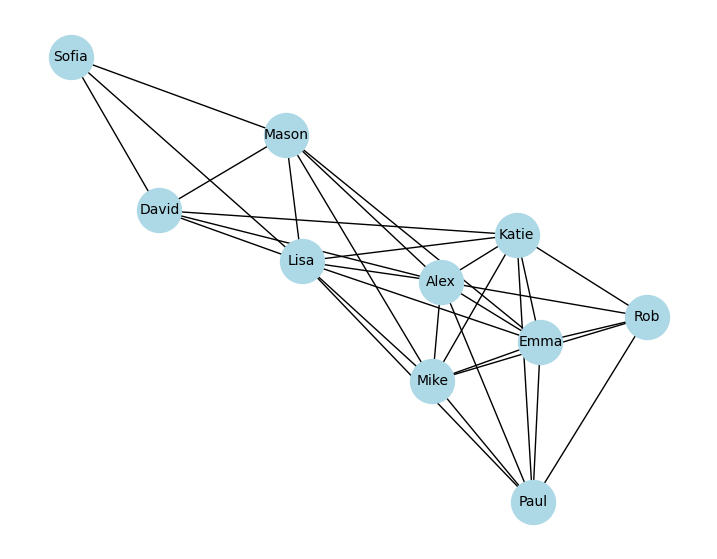

In [9]:
# draw a simple network diagram of the network
plt.figure(figsize=(9, 7))
nx.draw_networkx(g, 
                 with_labels=True, 
                 node_size=1000, 
                 node_color="lightblue", 
                 font_size=10)
plt.axis("off")
plt.show()

## Task 3

Based on the edge weights in the network, perform the following:

- Plot the edge weight distribution for the network.
- Identify the top 5 pairs of employees with the most frequent collaborations (i.e., the highest edge weights).

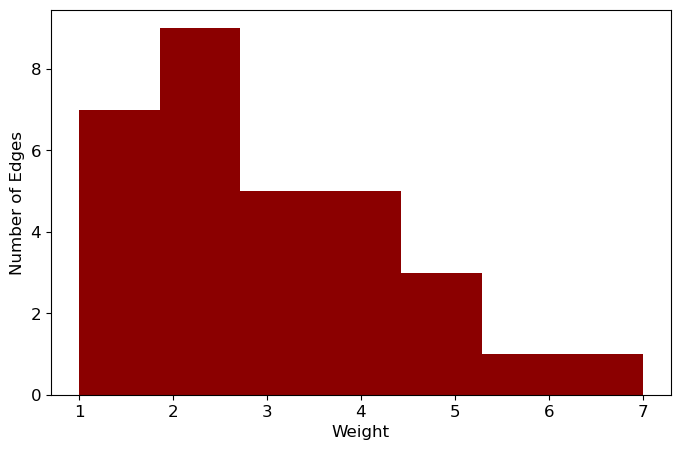

In [10]:
# there are various ways to do this
# one way is to build a dictionary from all the edge weights
weights = {}
for node1, node2, data in g.edges(data=True):
    # create a string from the 2 node names to use as a key
    key = f"{node1}, {node2}"    
    weights[key] = data["weight"]

# convert the dictionary to a Pandas Series for convenience
s_weights = pd.Series(weights)

# plot histogram of edge weight distribution
ax = s_weights.plot.hist(bins=7, figsize=(8, 5), fontsize=12, legend=None, color="darkred")
ax.set_ylabel("Number of Edges", fontsize=12)
ax.set_xlabel("Weight", fontsize=12)
plt.show()

In [11]:
# get the top-5 employee pairs
s_weights.sort_values(ascending=False).head(5)

Alex, Katie    7
Alex, Emma     6
Alex, Lisa     5
Lisa, Mason    5
Katie, Mike    5
dtype: int64

## Task 4

Create a new **unweighted** version of the network by applying **thresholding**, where only edges with weights >= 3 from the original network are preserved (i.e., pairs of employees must have collaborated on at least 3 projects). Exclude nodes which do not have any remaining edges in the new network.

For this new unweighted network:

- How many nodes and edges are in the new network?
- Get a list of the nodes in the network
- Create a simple network diagram of the new network

In [12]:
g2 = nx.Graph()
# iterate over the edges in the original network
for node1, node2, data in g.edges(data=True):
    # apply our edge weight threshold here
    if data["weight"] >= 4:
        g2.add_edge(node1, node2)

In [13]:
# how many nodes and edges in the new network?
print(f"Unweighted network has {g2.number_of_nodes()} nodes and {g2.number_of_edges()} edges")

Unweighted network has 8 nodes and 10 edges


In [14]:
# get a list of the node identifiers in this network
list(g2.nodes())

['Alex', 'Katie', 'Rob', 'Emma', 'Mike', 'Lisa', 'Mason', 'David']

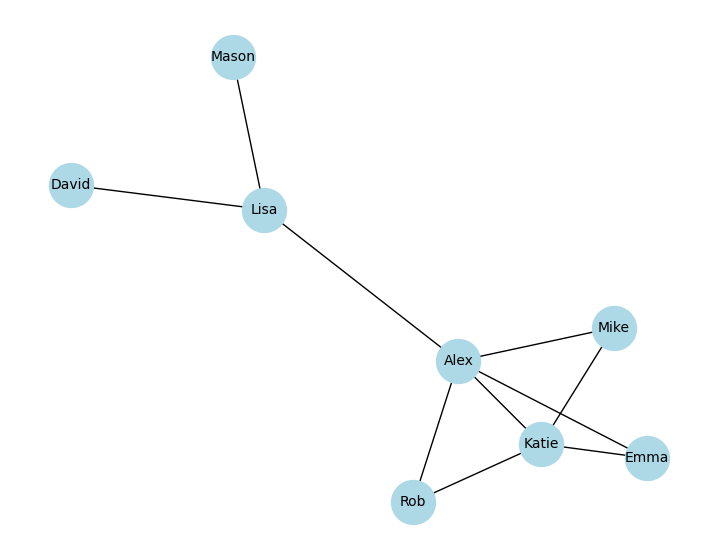

In [15]:
# draw a simple network diagram of the network
plt.figure(figsize=(9, 7))
nx.draw_networkx(g2, 
                 with_labels=True, 
                 node_size=1000, 
                 node_color="lightblue", 
                 font_size=10)
plt.axis("off")
plt.show()